In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from tqdm import tqdm

In [2]:
from selenium.webdriver.common.by import By

In [3]:
options = webdriver.EdgeOptions()

In [4]:
options.add_argument('--no-sandbox')
options.add_experimental_option('excludeSwitches', ['enable-automation'])
options.add_experimental_option('useAutomationExtension', False)

In [5]:
service = Service(r'./msedgedriver.exe') 
driver = webdriver.Edge(options=options,service=service)

In [6]:
driver.maximize_window()
driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
    "source": """
    Object.defineProperty(navigator, 'webdriver', {
        get: () => undefined
    })
    """
})

{'identifier': '2'}

In [7]:
driver.get('https://2025.ijcai.org/guangzhou-main-track-accepted-papers/')

In [8]:
btn = driver.find_element(By.XPATH,"/html/body/div/div/div/div/main/article/div/div/div[1]")

In [9]:
btn.text

'56: Multi-View Learning with Context-Guided Receptance for Image Denoising Preprint\nAuthors: Binghong Chen, Tingting Chai, Wei Jiang, Yuanrong Xu, Guanglu Zhou, Xiangqian Wu\nLocation: Guangzhou | Day: August 31st | Time: 09:40 | Session: CV: Low-level Vision (2/2)\nShow Abstract'

In [10]:
btn.text.split("\n")[0].split(":")[-1][:-9]

' Multi-View Learning with Context-Guided Receptance for Image Denoising'

In [11]:
title_list = []
xpath_tmp = "/html/body/div/div/div/div/main/article/div/div/div[{}]"
for i in tqdm(range(1,756)):
    xpath_id = xpath_tmp.format(i)
    btn = driver.find_element(By.XPATH,xpath_id)
    title_list.append(btn.text.split("\n")[0].split(":")[-1][:-9].strip())

100%|████████████████████████████████████████████████████████████████████████████████| 755/755 [00:14<00:00, 53.59it/s]


In [12]:
title_list

['Multi-View Learning with Context-Guided Receptance for Image Denoising',
 'A Universal Spatio-Temporal Modeling Framework',
 'Robustness to Spurious Correlations via Dynamic Knowledge Transfer',
 'Multi-layer Visual Preference-enhanced Concept Bottleneck Model for Explainable Medical Image Classification',
 'Variational Graph Auto-Encoder Driven Graph Enhancement for Sequential Recommendation',
 'Adversarial Propensity Weighting for Debiasing in Collaborative Filtering',
 'Revisiting Incomplete Multimodality-Diffusion Emotion Recognition from the Perspective of Graph Spectrum',
 'A Methodological Framework for Measuring Spatial Labeling Similarity',
 'Dual-Perspective United Transformer for Object Segmentation in Optical Remote Sensing Images',
 'A Clean-View Perspective',
 'A Dynamic Knowledge Update-Driven Model with Large Language Models for Fake News Detection',
 'Multi-Modal Point Cloud Completion with Interleaved Attention Enhanced Transformer',
 'Active Collection Based Human-

In [13]:
driver.close()

In [14]:
import json

In [15]:
with open("ijcai_2025_title.json", 'w') as  f:
    json.dump(title_list, f)

In [16]:
from wordcloud import (WordCloud, get_single_color_func, STOPWORDS, ImageColorGenerator)
import matplotlib.pyplot as plt

In [17]:
txt_stop = """a an . , : ? the is in to of via be from by with and or for - on"""

In [18]:
text_all = " ".join(title_list)

In [19]:
stop_words_list = txt_stop.split(" ")
stopwords = set(STOPWORDS)
for w in stop_words_list:
    stopwords.add(w)

In [20]:
wordcloud = WordCloud(
    background_color="white",
    width=1000, 
    height=860, 
    margin=2,
    max_font_size=196,
    max_words=256,
    random_state=96,
    stopwords=stopwords,
).generate(text_all.lower())

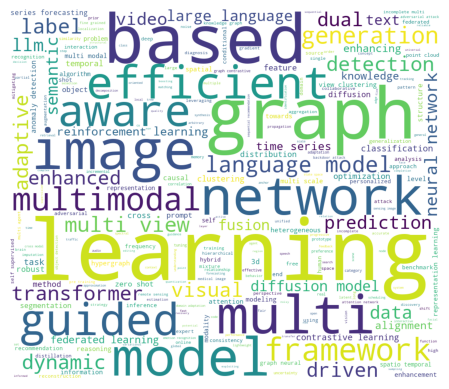

In [21]:
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [22]:
wordcloud.to_file('wordcloud_ijcai2025_title.pdf')

In [23]:
from collections import Counter

In [24]:
wordcount = Counter([i.lower() for i in text_all.split(" ") if i.lower() not in stop_words_list])

In [25]:
wordcount

Counter({'learning': 194,
         'graph': 96,
         'models': 59,
         'detection': 50,
         'network': 46,
         'image': 45,
         'diffusion': 39,
         'knowledge': 36,
         'model': 36,
         'multimodal': 36,
         'neural': 35,
         'framework': 34,
         'federated': 34,
         'generation': 34,
         'language': 33,
         'multi-view': 31,
         'clustering': 31,
         'networks': 31,
         'large': 30,
         'efficient': 30,
         'visual': 27,
         'dynamic': 26,
         'prediction': 25,
         'transformer': 24,
         'video': 24,
         'adaptive': 23,
         'reinforcement': 23,
         'contrastive': 23,
         'fusion': 22,
         'data': 22,
         'time': 22,
         'segmentation': 21,
         'forecasting': 21,
         'representation': 21,
         'series': 21,
         'alignment': 20,
         'enhancing': 20,
         'semantic': 20,
         'feature': 19,
         'classifi